#  Impact-T `sc_inj/v0new`

In [2]:
# Nicer plotting
import matplotlib.pyplot as plt
import matplotlib
%matplotlib inline
%config InlineBackend.figure_format = 'retina'

In [3]:
%load_ext autoreload
%autoreload 2

In [4]:
from impact import Impact
from distgen import Generator
from pmd_beamphysics import ParticleGroup, single_particle
import numpy as np

In [5]:
#P0 = ParticleGroup( '$LCLS_LATTICE/bmad/models/sc_inj/cathode_probe_particles.h5')
#P0.weight = 1.0
#P0.pz = 1
#P0.pz

In [6]:
Impact.command_env     = 'NEW_IMPACTT_BIN'
Impact.command_mpi_env = 'NEW_IMPACTT_MPI_BIN'

# Distgen particles

In [7]:
DISTGEN_IN = '$LCLS_LATTICE/distgen/models/sc_inj/v0/distgen.yaml'

G = Generator(DISTGEN_IN)

G['start:MTE:value'] = 185
G['n_particle'] = 10_000
G

<disgten.Generator with input: 
n_particle: 10000
r_dist:
  max_r:
    units: mm
    value: 0.5
  type: radial_uniform
random_type: hammersley
start:
  MTE:
    units: meV
    value: 185
  type: cathode
t_dist:
  avg_t:
    units: ps
    value: 0
  n_sigma_cutoff: 3
  sigma_t:
    units: ps
    value: 8.5
  type: gaussian
total_charge:
  units: pC
  value: 100

>

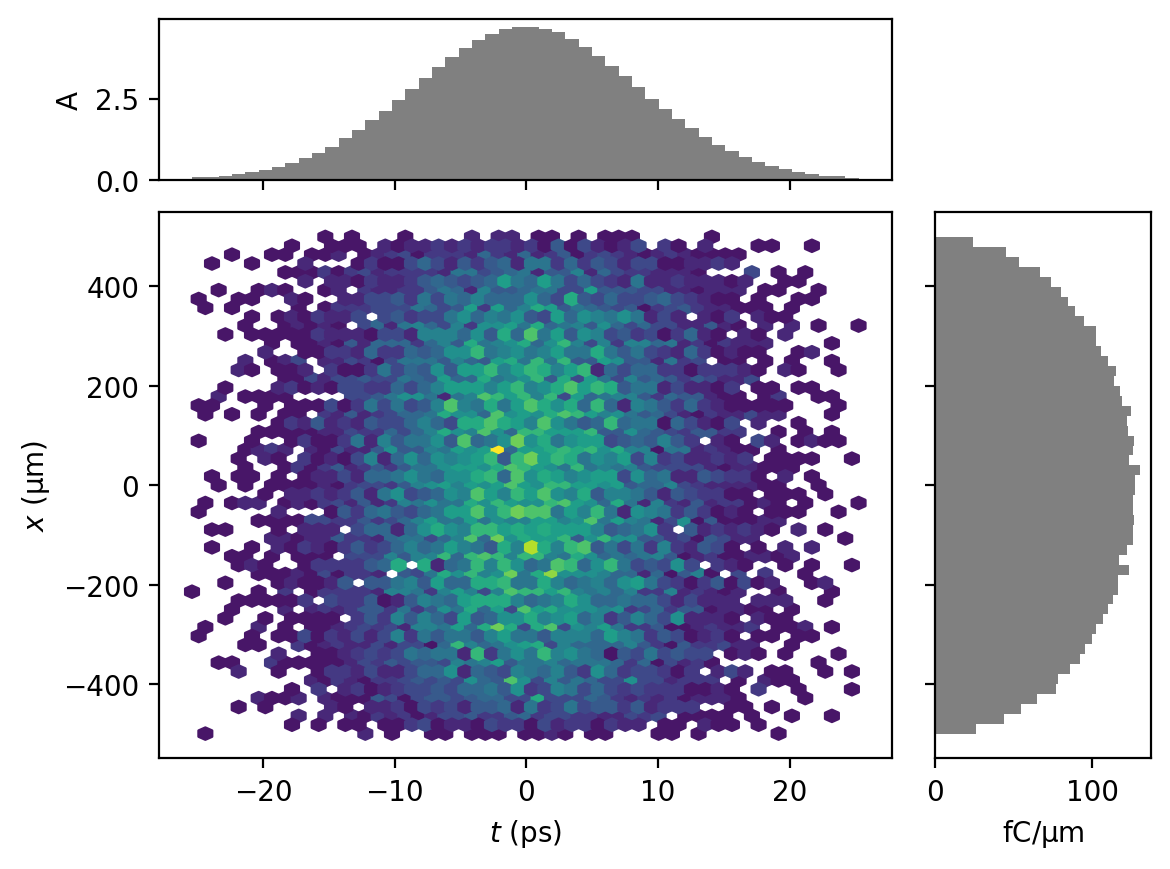

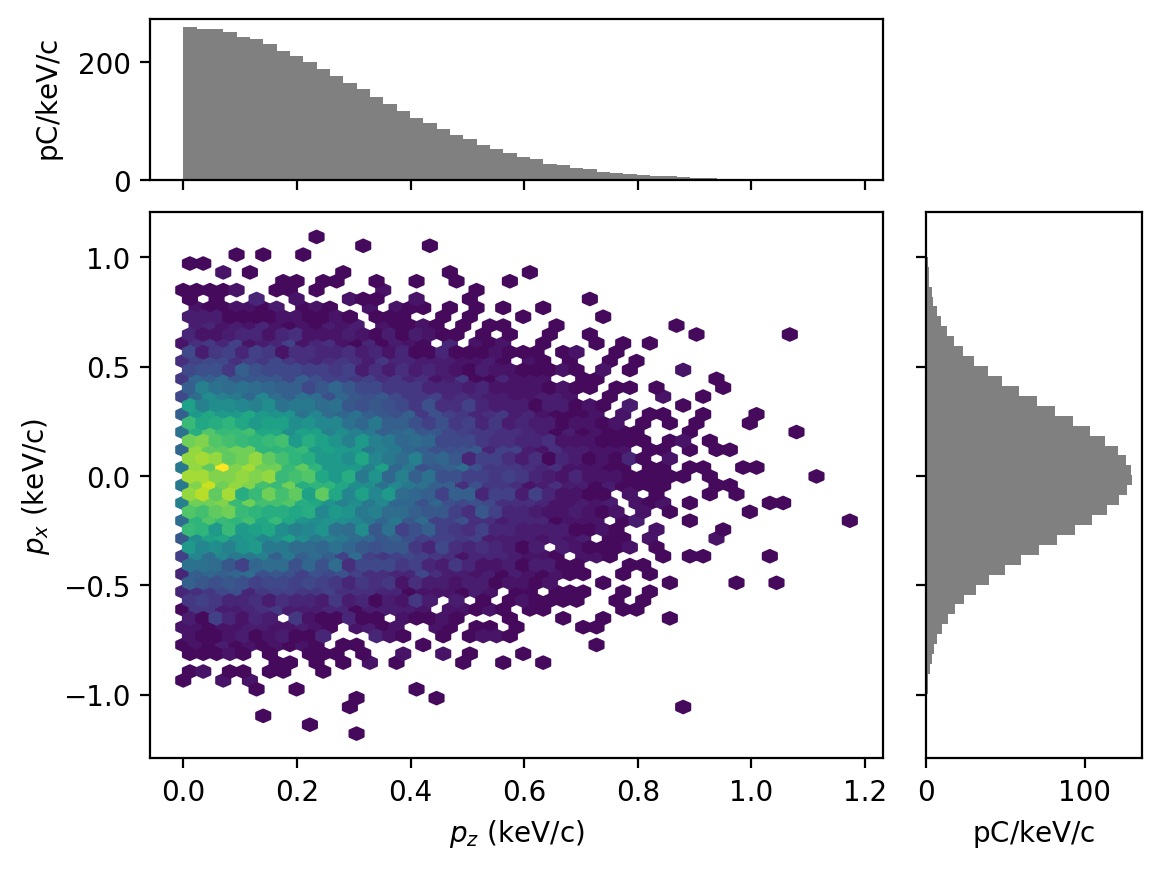

In [8]:
# Make the particles
G.run()
P0 = G.particles
P0.plot('t', 'x')
P0.plot('pz', 'px')

# original 

# Impact

================ Impact-T Summary ================    
10000 particles
1 bunch of electrons
total charge: 100.0 pC
Distribution type: uniform_waterbag_gauss3
Cathode start at z = 0 m
   emission time: 5.5e-11 s
   image charges neglected after z = 0.02 m
Processor domain: 2 x 4 = 8 CPUs
Space charge grid: 32 x 32 x 32
Maximum time steps: 2000000
Reference Frequency: 1300000000.0 Hz
Initial reference time: -1.0000000000000167e-12 s
Simulation starting from the beginning
Impact-T configured in /var/folders/2f/l5_mybzs30j4qqvyj98w1_nw0000gn/T/tmp5po2j4mx


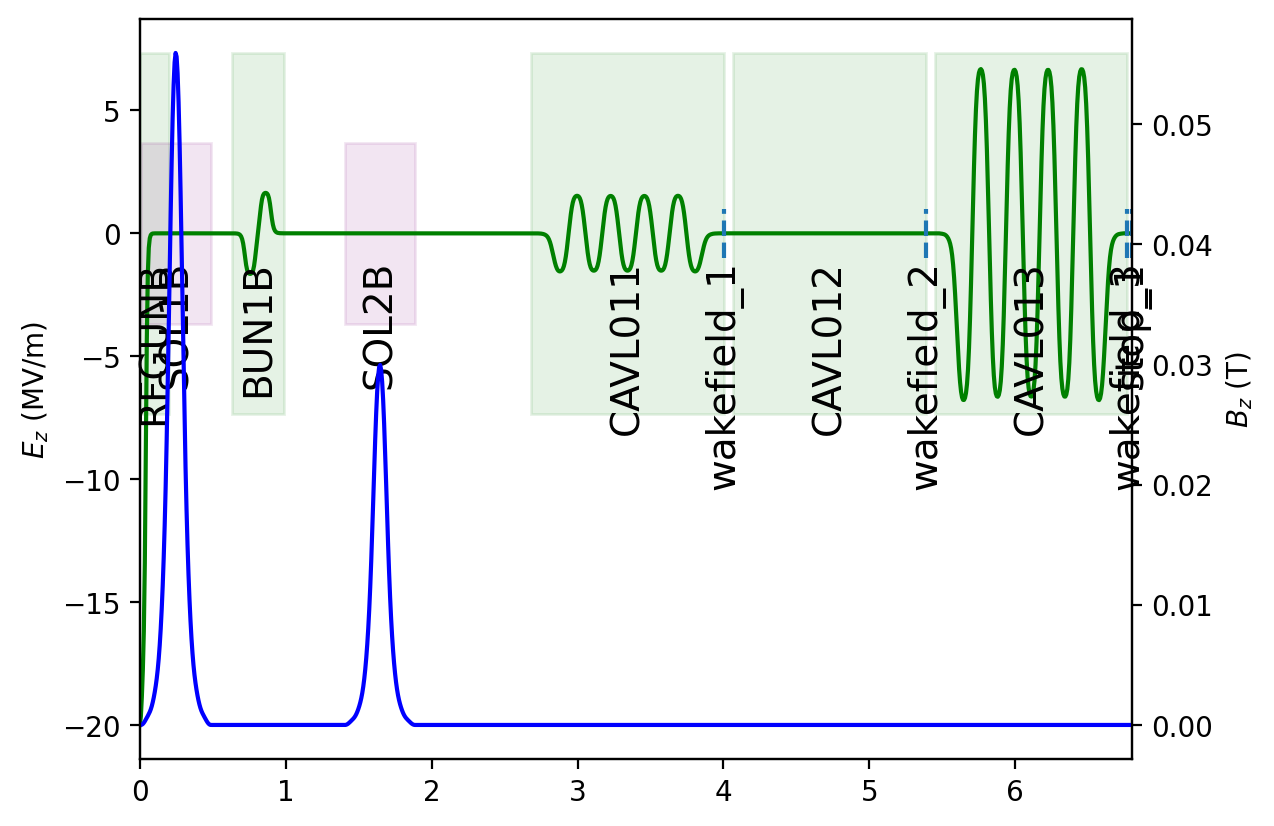

In [9]:
IMPACT_IN = '$LCLS_LATTICE/impact/models/sc_inj/v0new/ImpactT.in'

ZSTOP = 6.8

I = Impact(IMPACT_IN)
I.header['Np'] = 10_000
I.header['Nx'] = 32
I.header['Ny'] = 32
I.header['Nz'] = 32

I.ele['stop_1']['s'] = ZSTOP
I.header['Bcurr'] = 0.13

I.verbose=False
I.numprocs = 8

print(I)
I.plot(xlim=(0, ZSTOP), include_labels=True)

CPU times: user 352 ms, sys: 160 ms, total: 512 ms
Wall time: 31.3 s


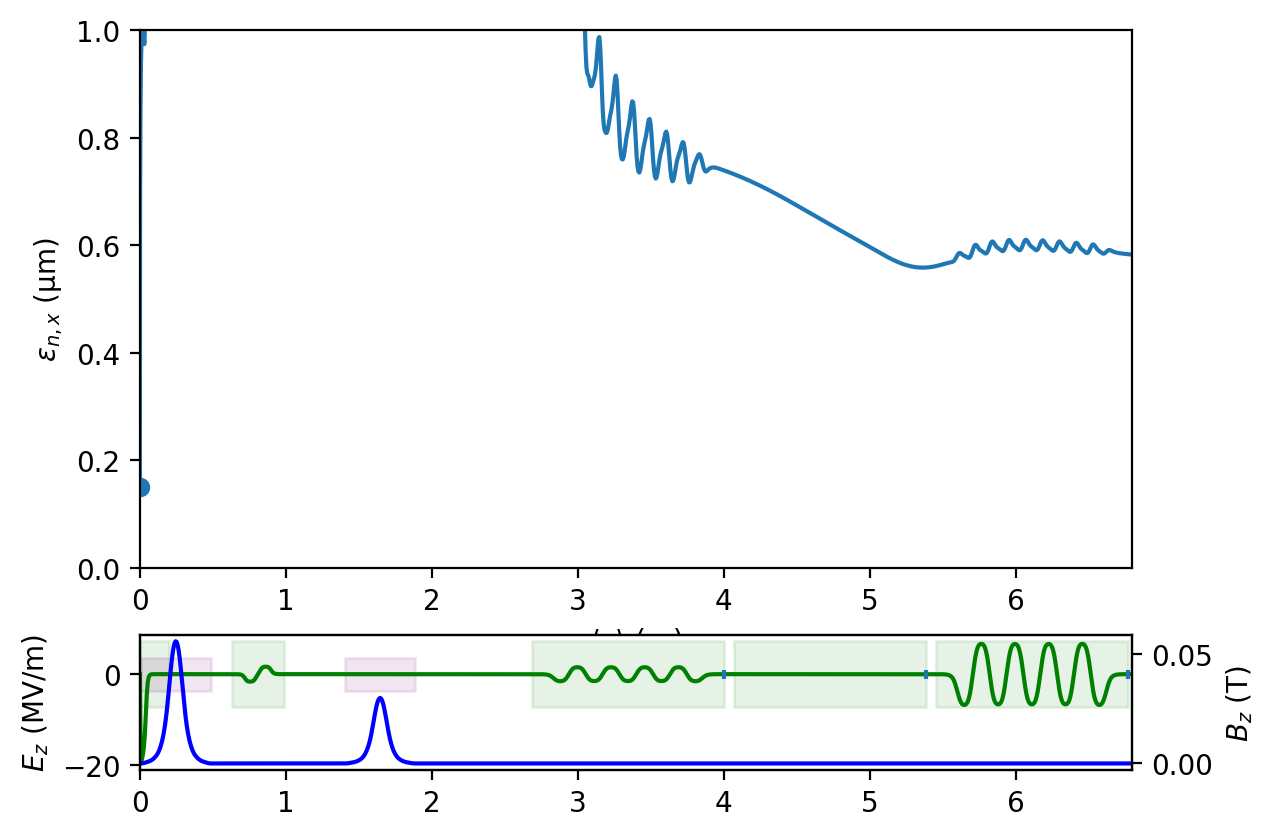

In [10]:
%%time
I.run()
I.plot('norm_emit_x', ylim=(0, 1e-6))

# Examine fieldmaps

In [11]:
from impact.fieldmaps import solrf_field_from_data
from impact.tools import safe_loadtxt


fmap1 = solrf_field_from_data(safe_loadtxt('v0new/rfdata5'))
fmap2 = solrf_field_from_data(safe_loadtxt('v1new/rfdata2'))

In [12]:
fmap1['Ez'].keys()

dict_keys(['z0', 'z1', 'L', 'derivative_array'])

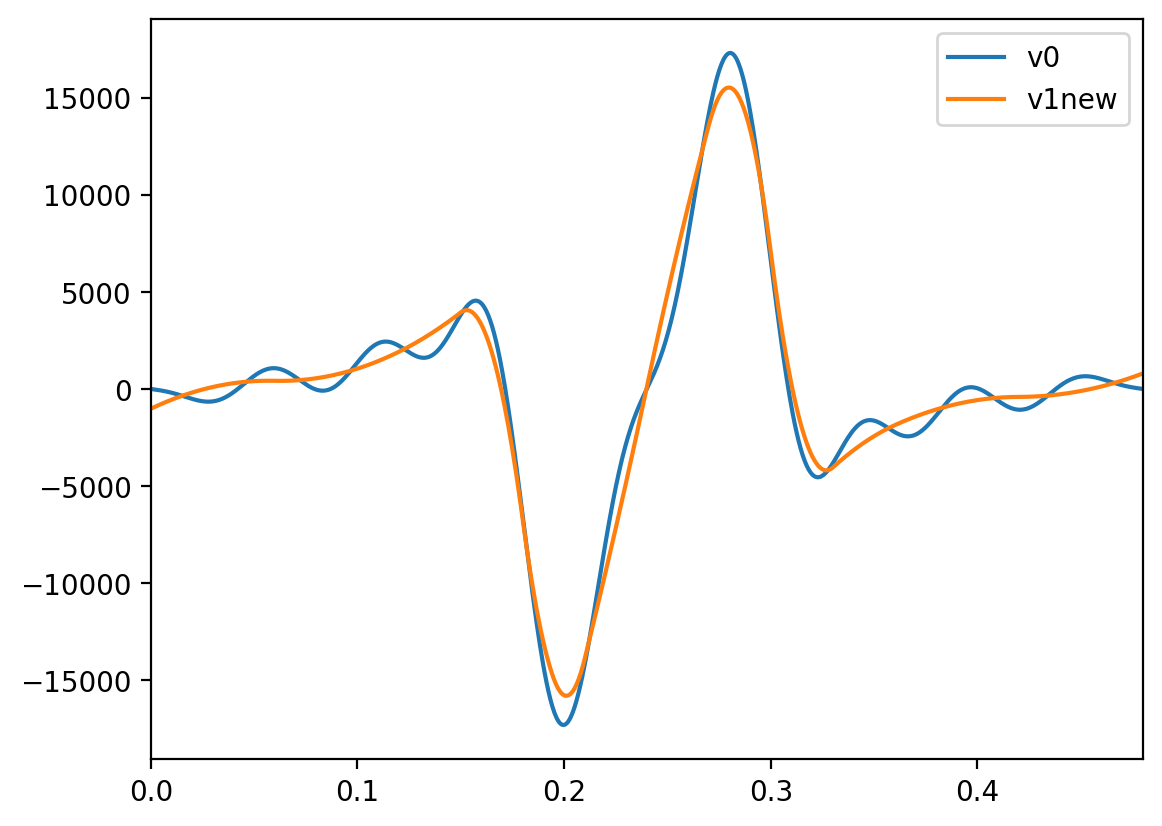

In [13]:
for label, fmap in [( 'v0', fmap1), ('v1new', fmap2) ]:
    Fz = fmap['Bz']
    z0 = Fz['z0']
    z1 = Fz['z1']
    darray = Fz['derivative_array']
    z = np.linspace(z0, z1, len(darray))
    plt.plot(z, darray[:,3], label=label)
    plt.xlim(0, z1)
plt.legend()

# Plots

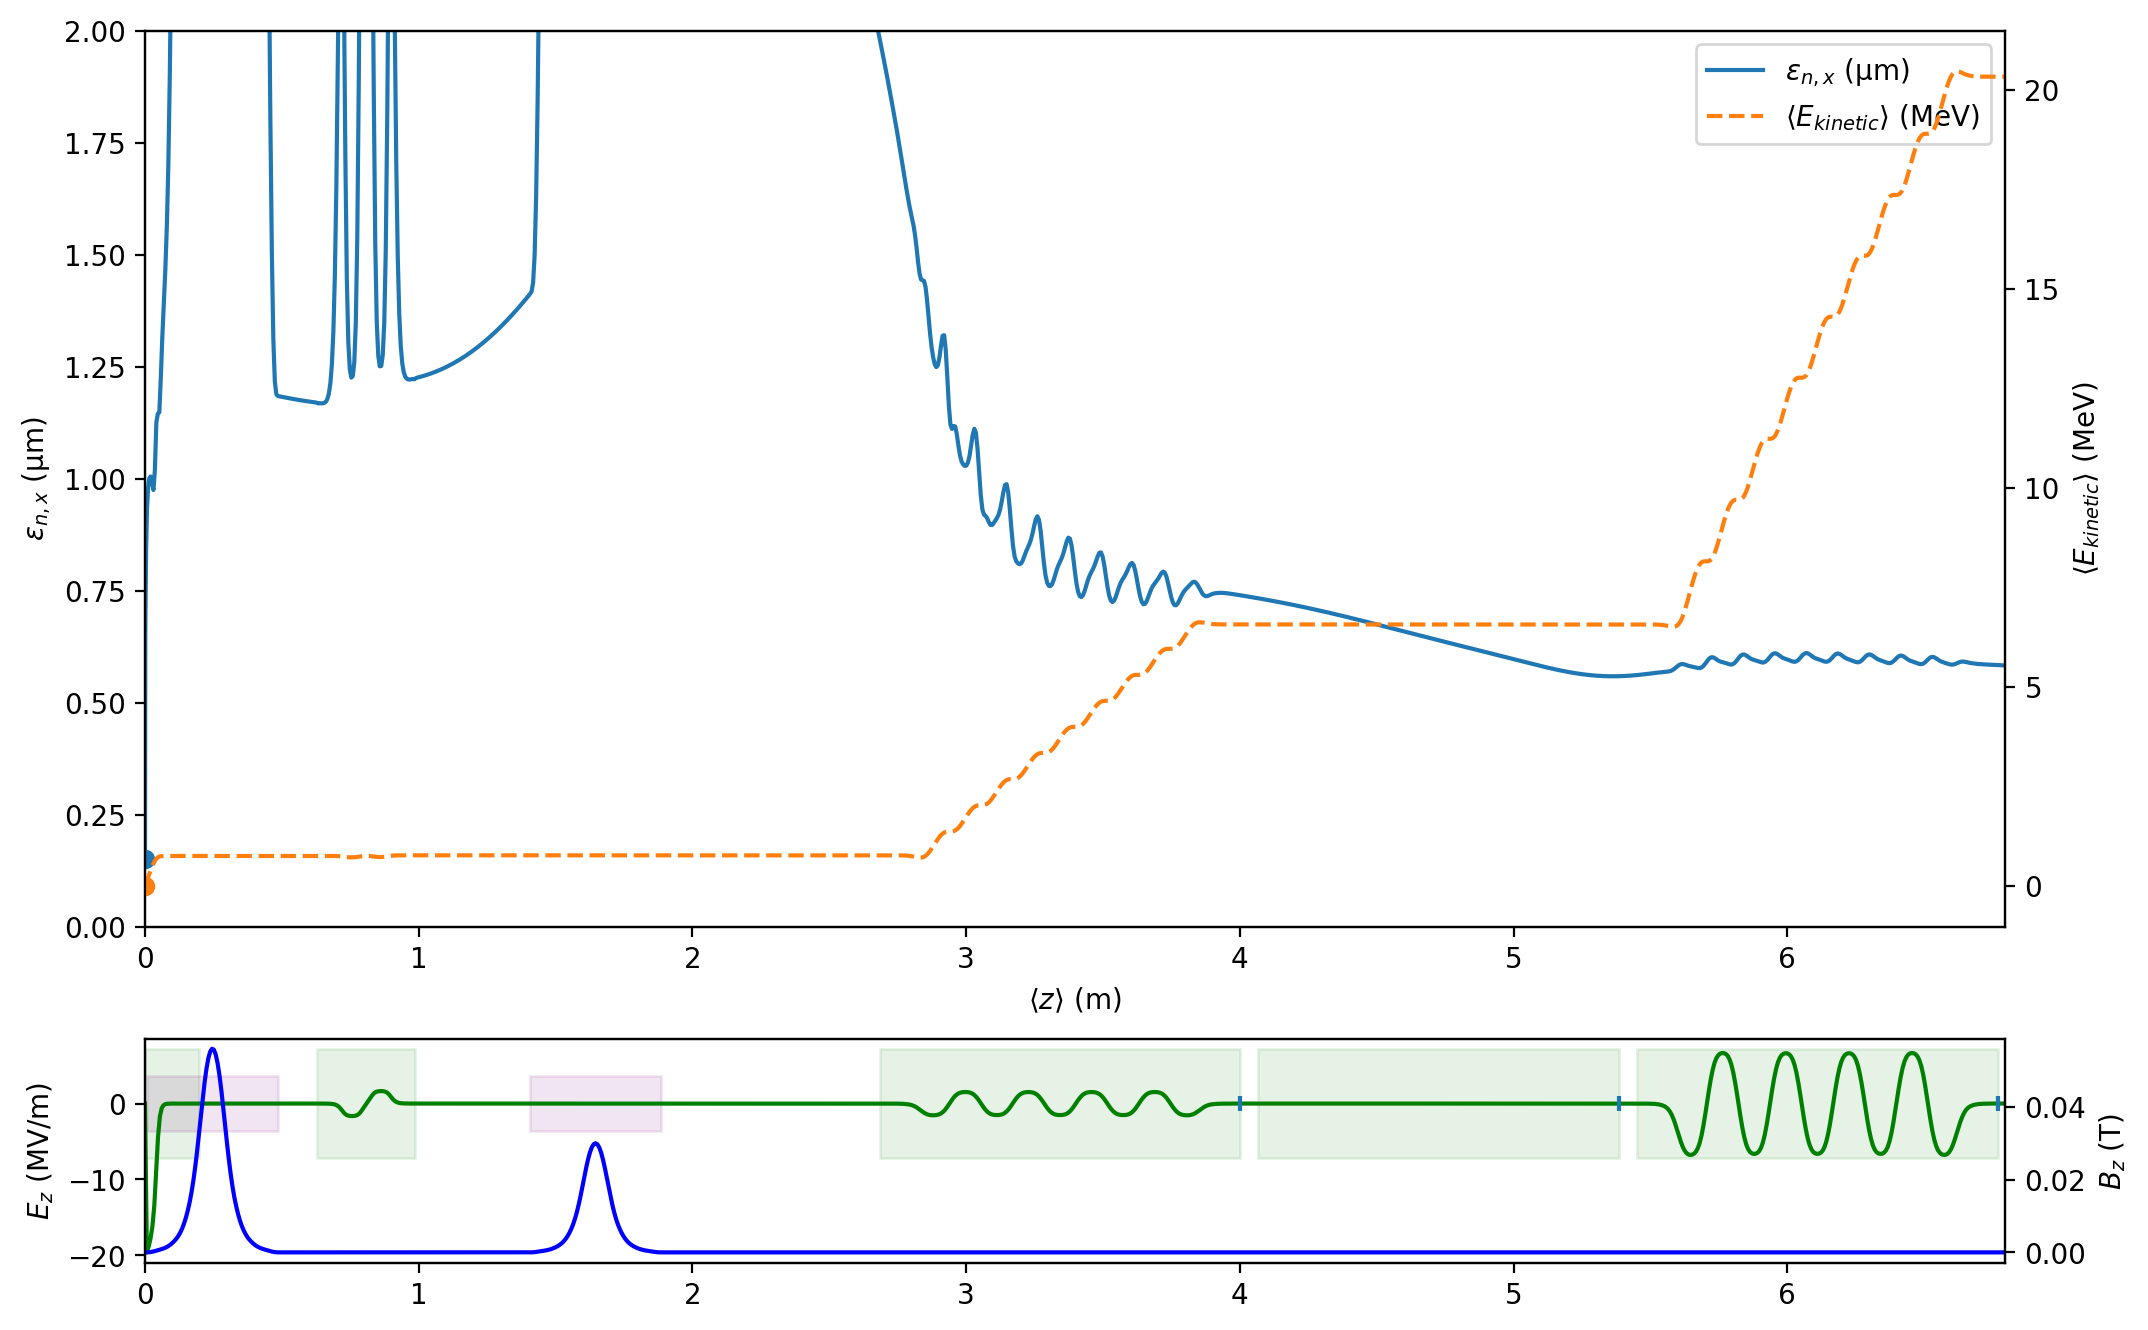

In [14]:
I.plot('norm_emit_x', y2='mean_kinetic_energy', ylim=(0, 2e-6), figsize=(12,8))

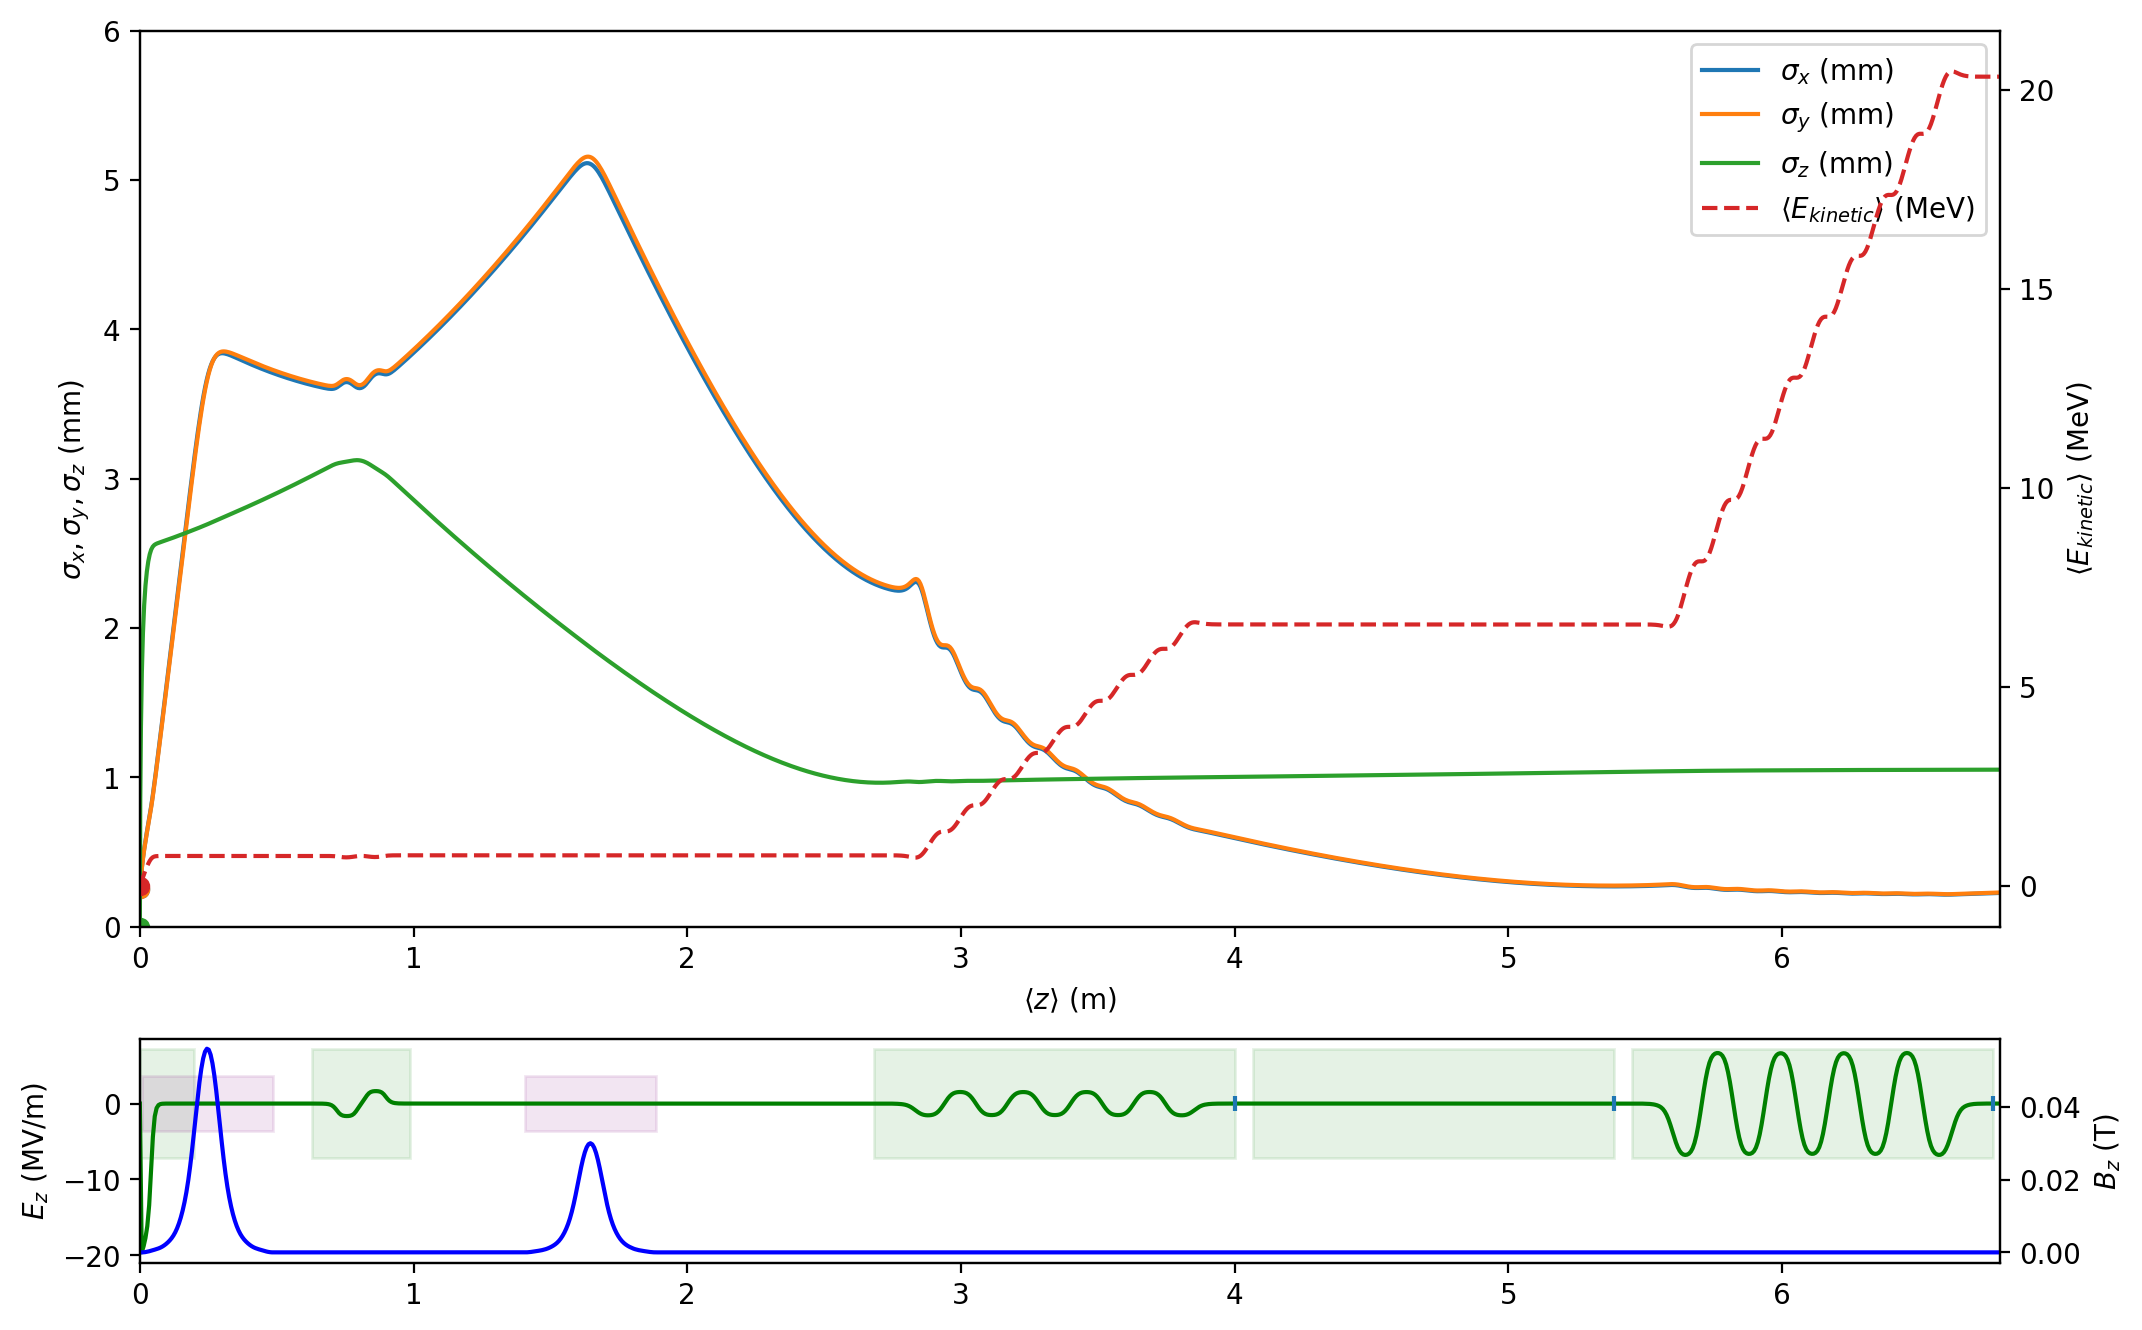

In [15]:
I.plot(['sigma_x', 'sigma_y', 'sigma_z'], y2='mean_kinetic_energy', ylim=(0, 6e-3), figsize=(12,8))

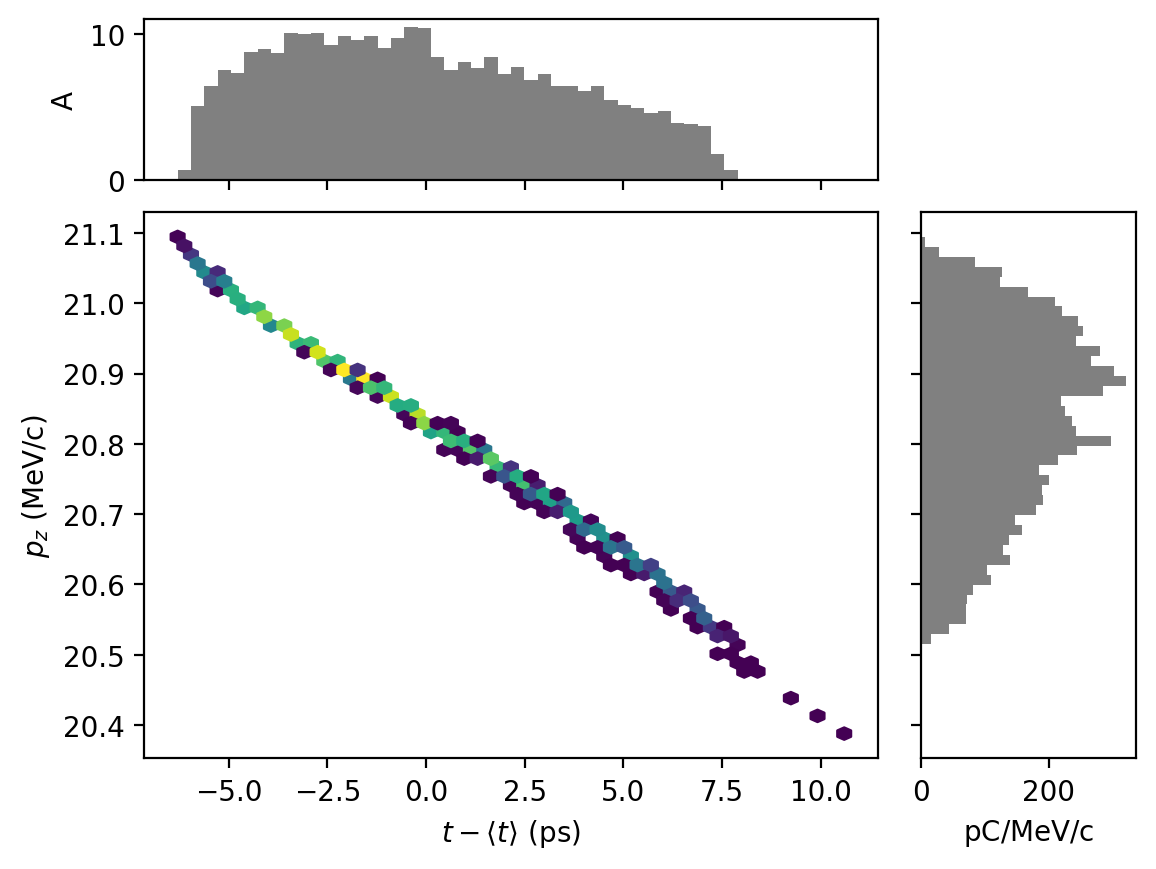

In [16]:
Pf = I.particles['final_particles'].copy()
Pf.drift_to_z()
Pf.plot('delta_t', 'pz')

# Scan initial timing

In [ ]:
from concurrent.futures import ProcessPoolExecutor
# Allows processes to work with macOS
from sys import platform 
if platform == 'darwin':
    import multiprocessing as mp
    mp.set_start_method("fork")

In [ ]:
Iref = I.copy()
Iref.initial_particles = P0.copy()

In [ ]:
%%time
def set1(x_deg): 
    Itest = Iref.copy()
    Itest.verbose=False
    Itest.configure()
    Itest.numprocs = 1
    Itest.initial_particles.t +=  (1/187e6)/360 * x_deg
    Itest.run()
    return Itest
set1(0)

In [ ]:
xlist = np.linspace(1.5, 2, 8)
xlist

In [ ]:
%%time
with ProcessPoolExecutor(max_workers=8) as executor:
    results1 = list(executor.map(set1, xlist))    

In [ ]:
def compare(ykey, xkey = 'mean_z', ylim=None):
    xunits = I.units(xkey)
    yunits = I.units(ykey)
    
    fig, ax = plt.subplots(figsize=(12,8))
    
    for name, I9 in enumerate(results1):
        ax.plot(I9.stat(xkey), I9.stat(ykey), label='x')
    ax.set_xlabel(f'{xkey} ({xunits})')
    ax.set_ylabel(f'{ykey} ({yunits})')
    ax.set_ylim(ylim)
    plt.legend()
    
compare('norm_emit_x', ylim=(5e-7, 3e-6)    )
#plt.yscale('log')

In [ ]:
results1
y1 = np.array(list(map(lambda ii: ii.particles['final_particles'].twiss('x', 1)['norm_emit_x'], results1)))
y2 = np.array(list(map(lambda ii: ii.particles['final_particles'].twiss('x', 0.95)['norm_emit_x'], results1)))
plt.plot(xlist, y1)
plt.plot(xlist, y2)

In [ ]:
y1.argmin()

In [ ]:
xlist[y1.argmin()]

In [ ]:
x0

In [ ]:
I2 = results1[4]
I2.plot('norm_emit_x', y2='mean_kinetic_energy', ylim=(0, 2e-6), figsize=(12,8))

In [ ]:
a = 0.8e-3
0.511e6 * a**2 

In [ ]:
np.sqrt(0.185/0.5116)